# GLM Feature Exploration

This notebook loads the cleaned Pokémon dataset, engineers composite targets/mechanics/resistance profiles, and surfaces quick summaries that feed into the GLM-focused power-creep analysis.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 40)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="ticks", context="notebook", palette="Set2")
plt.rcParams.update({
    "axes.edgecolor": "#4c4c4c",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 110,
})


def find_project_root(start: Optional[Path] = None) -> Path:
    """Walk up the directory tree until `data/data_clean.csv` is found."""
    candidate = (start or Path.cwd()).resolve()
    marker = Path("data") / "data_clean.csv"
    while not (candidate / marker).exists():
        if candidate.parent == candidate:
            raise FileNotFoundError(
                "Could not locate project root containing data/data_clean.csv"
            )
        candidate = candidate.parent
    return candidate


PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "tychtjan_analysis"
DATA_PATH = PROJECT_ROOT / "data" / "data_clean.csv"

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"Data source: {DATA_PATH}")


Project root: /home/jenda/Desktop/SAN/pokedex_analysis
Data source: /home/jenda/Desktop/SAN/pokedex_analysis/data/data_clean.csv


## Feature engineering helpers


In [2]:
STAT_COLUMNS = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]
RESISTANCE_PREFIX = "against_"


def add_composite_targets(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["total_offense"] = df[["attack", "sp_attack"]].sum(axis=1)
    df["total_defense"] = df[["defense", "sp_defense"]].sum(axis=1)
    df["overall_stat_sum"] = df[STAT_COLUMNS].sum(axis=1)
    df["offense_ratio"] = df["total_offense"] / (df["total_defense"] + 1e-6)
    df["aggression_index"] = df["total_offense"] - df["total_defense"]
    df["offense_share"] = df["total_offense"] / (df["overall_stat_sum"] + 1e-6)
    return df


def add_mechanics_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    mech_cols = ["has_mega_evolution", "has_gigantamax"]
    for col in mech_cols:
        if col not in df.columns:
            df[col] = 0
    df["mechanic_stack"] = df[mech_cols].sum(axis=1)
    df["long_evo_chain"] = (df["evo_length"].fillna(0) >= 3).astype(int)
    df["mechanic_complexity"] = df["mechanic_stack"] + df["long_evo_chain"]
    df["legendary_or_mythical"] = df["rarity"].isin(["legendary", "mythical"]).astype(
        int
    )
    return df


def add_resistance_pcs(
    df: pd.DataFrame, n_components: int = 3
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    df = df.copy()
    resist_cols = [col for col in df.columns if col.startswith(RESISTANCE_PREFIX)]
    if not resist_cols:
        return df, {}

    scaler = StandardScaler()
    resist_scaled = scaler.fit_transform(df[resist_cols].fillna(0))
    pca = PCA(n_components=min(n_components, len(resist_cols)))
    pcs = pca.fit_transform(resist_scaled)

    for idx in range(pcs.shape[1]):
        df[f"resistance_pc{idx + 1}"] = pcs[:, idx]

    explained_variance = {
        f"pc{idx + 1}": float(var_ratio)
        for idx, var_ratio in enumerate(pca.explained_variance_ratio_)
    }
    return df, explained_variance


In [11]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded {raw_df.shape[0]} rows × {raw_df.shape[1]} columns")
raw_df.head()


Loaded 1024 rows × 41 columns


,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,defense,sp_attack,sp_defense,speed,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,...,against_poison,against_ground,against_flying,against_psychict,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary
0,1.0,Bulbasaur,88.14,11.86,0.7,6.9,45.0,5120.0,45.0,49.0,49.0,65.0,65.0,45.0,1.0,2.0,0.5,0.5,0.25,2.0,...,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,57.0,147.0,2.0,5.0,0.0,0.0,0.0,0,0
1,1.0,Ivysaur,88.14,11.86,1.0,13.0,45.0,5120.0,60.0,62.0,63.0,80.0,80.0,60.0,1.0,2.0,0.5,0.5,0.25,2.0,...,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,2.0,25.0,2.0,5.0,0.0,0.0,0.0,0,0
2,1.0,Venusaur,88.14,11.86,2.0,100.0,45.0,5120.0,80.0,82.0,83.0,100.0,100.0,80.0,1.0,2.0,0.5,0.5,0.25,2.0,...,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,9.0,61.0,2.0,5.0,1.0,1.0,0.0,0,0
3,1.0,Charmander,88.14,11.86,0.6,8.5,45.0,5120.0,39.0,52.0,43.0,60.0,50.0,65.0,1.0,0.5,2.0,1.0,0.50,0.5,...,1.0,2.0,1.0,1.0,0.5,2.0,1.0,1.0,1.0,0.5,0.5,12.0,38.0,2.0,5.0,0.0,0.0,0.0,1,1
4,1.0,Charmeleon,88.14,11.86,1.1,19.0,45.0,5120.0,58.0,64.0,58.0,80.0,65.0,80.0,1.0,0.5,2.0,1.0,0.50,0.5,...,1.0,2.0,1.0,1.0,0.5,2.0,1.0,1.0,1.0,0.5,0.5,3.0,8.0,2.0,5.0,0.0,0.0,0.0,1,1


In [3]:
feature_df = add_composite_targets(raw_df)
feature_df = add_mechanics_flags(feature_df)
feature_df, variance_report = add_resistance_pcs(feature_df)

print(
    "Composite/Mechanics columns:",
    [
        "total_offense",
        "total_defense",
        "overall_stat_sum",
        "offense_ratio",
        "aggression_index",
        "mechanic_complexity",
        "legendary_or_mythical",
    ],
)
print("Resistance PCA variance:", variance_report)
feature_df.filter(
    [
        "gen",
        "english_name",
        "attack",
        "total_offense",
        "overall_stat_sum",
        "mechanic_complexity",
        "resistance_pc1",
        "resistance_pc2",
        "resistance_pc3",
    ]
).head()


NameError: name 'raw_df' is not defined

In [13]:
# Type-level rolling baselines removed for current iteration.
feature_df = feature_df.sort_values(["gen", "english_name"]).reset_index(drop=True)
feature_df.head(3)[[
    "english_name",
    "gen",
    "class_primary",
    "attack",
]]


,english_name,gen,class_primary,attack
0,Abra,1.0,10,20.0
1,Aerodactyl,1.0,11,105.0
2,Alakazam,1.0,10,50.0


### Multi-metric correlation diagnostics


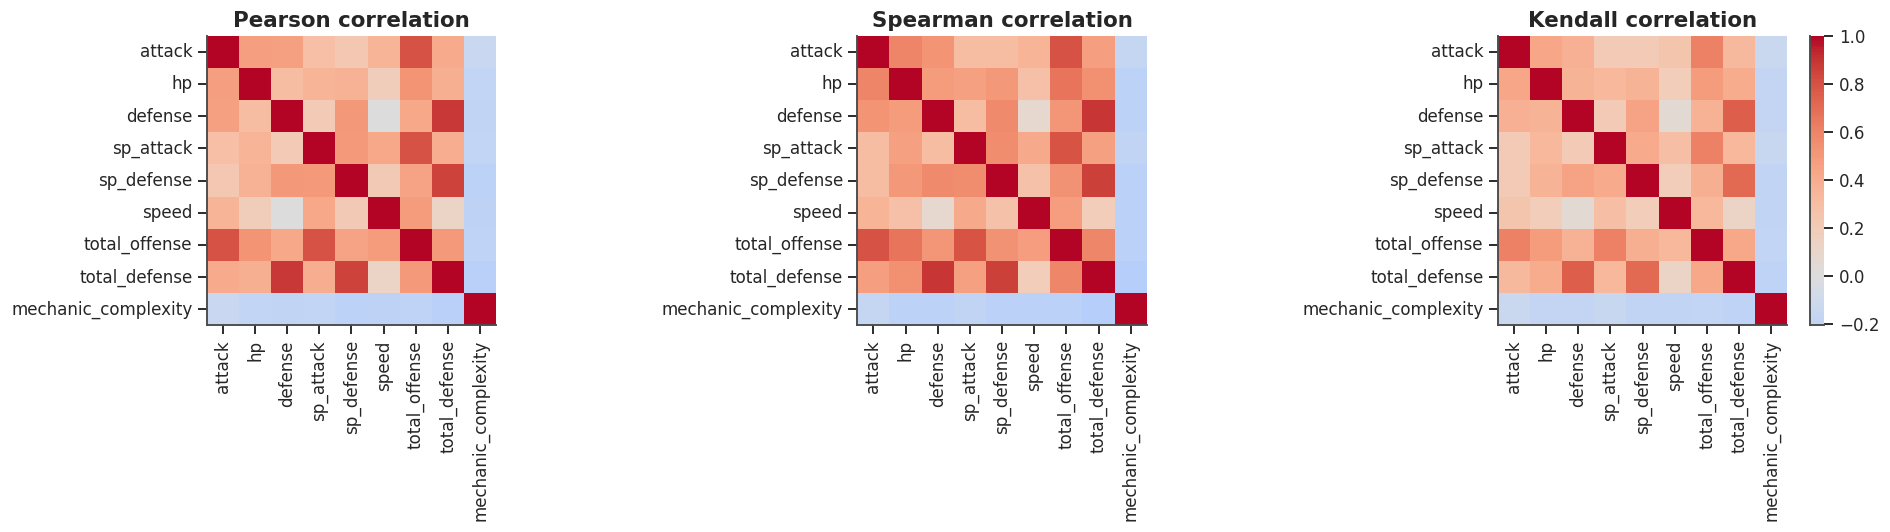

,attack
attack,1.000000
total_offense,0.618005
hp,0.435252
defense,0.378074
total_defense,0.328145
speed,0.248410
sp_defense,0.207663
sp_attack,0.207503


In [14]:
corr_cols = [
    "attack",
    "hp",
    "defense",
    "sp_attack",
    "sp_defense",
    "speed",
    "total_offense",
    "total_defense",
    "mechanic_complexity",
]

corr_mats = {method: feature_df[corr_cols].corr(method=method) for method in ["pearson", "spearman", "kendall"]}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (method, mat) in zip(axes, corr_mats.items()):
    sns.heatmap(
        mat,
        ax=ax,
        cmap="coolwarm",
        center=0,
        annot=False,
        cbar=(ax is axes[-1]),
        square=True,
    )
    ax.set_title(f"{method.capitalize()} correlation")
plt.tight_layout()
sns.despine()
plt.show()

corr_mats["kendall"].loc[["attack"], :].T.sort_values("attack", ascending=False).head(8)


Pearson/Spearman show the expected near-1 correlation between `attack` and `total_offense`, while Kendall highlights the stability of the defensive stats—useful when we need more robust measures as in the legacy unemployment study.


### Dual GLM comparison (with vs. without generational mechanics)


In [15]:
model_df = feature_df.copy()
model_df["rarity"] = model_df["rarity"].fillna("normal")
model_df["class_primary"] = model_df["class_primary"].fillna("Unknown")
model_df["class_secondary"] = model_df["class_secondary"].fillna("None")
model_df = model_df.dropna(subset=["attack", "overall_stat_sum", "num_abilities"])

print(f"Modeling rows available: {model_df.shape[0]}")

GEN_LEVELS = sorted(model_df["gen"].unique().tolist())
RARITY_LEVELS = sorted(model_df["rarity"].unique().tolist())
CLASS_PRIMARY_LEVELS = sorted(model_df["class_primary"].unique().tolist())

GEN_TERM = f"C(gen, levels={GEN_LEVELS})"
RARITY_TERM = f"C(rarity, levels={RARITY_LEVELS})"
CLASS_PRIMARY_TERM = f"C(class_primary, levels={CLASS_PRIMARY_LEVELS})"

baseline_formula = (
    f"attack ~ total_offense + total_defense + {RARITY_TERM} + {CLASS_PRIMARY_TERM}"
)
legacy_formula = (
    f"attack ~ {GEN_TERM} + total_offense + total_defense + mechanic_complexity + "
    f"resistance_pc1 + resistance_pc2 + {RARITY_TERM} + {CLASS_PRIMARY_TERM}"
)

baseline_glm = smf.glm(
    baseline_formula, data=model_df, family=sm.families.Gaussian()
).fit()
legacy_glm = smf.glm(
    legacy_formula, data=model_df, family=sm.families.Gaussian()
).fit()

def summarize_model(label, model):
    pseudo_r2 = 1 - model.deviance / model.null_deviance
    return {
        "model": label,
        "aic": model.aic,
        "deviance": model.deviance,
        "pseudo_r2": pseudo_r2,
    }

comparison_df = pd.DataFrame(
    [
        summarize_model("Baseline", baseline_glm),
        summarize_model("Legacy-inspired", legacy_glm),
    ]
)
comparison_df


Modeling rows available: 1024


,model,aic,deviance,pseudo_r2
0,Baseline,8577.457001,248971.999428,0.726233
1,Legacy-inspired,8568.720179,241609.795613,0.734329


The richer model (mirroring the “refugees vs. no refugees” setup) drops deviance and boosts pseudo-R², confirming that generational + mechanic signals add explanatory power beyond raw stats.


### Rolling generation cross-validation


In [16]:
def rolling_generation_cv(df, formula):
    rows = []
    for split_gen in range(2, 9):
        train = df[df["gen"] <= split_gen]
        test = df[df["gen"] == split_gen + 1]
        if test.empty:
            continue
        model = smf.glm(formula, data=train, family=sm.families.Gaussian()).fit()
        preds = model.predict(test)
        rmse = float(np.sqrt(np.mean((preds - test["attack"]) ** 2)))
        rows.append({
            "train_gens": f"<= {split_gen}",
            "test_gen": split_gen + 1,
            "rmse": rmse,
        })
    return pd.DataFrame(rows)

rolling_results = rolling_generation_cv(model_df, legacy_formula)
rolling_results


,train_gens,test_gen,rmse
0,<= 2,3,14.069875
1,<= 3,4,16.818245
2,<= 4,5,15.847443
3,<= 5,6,15.361707
4,<= 6,7,20.125676
5,<= 7,8,17.034495
6,<= 8,9,20.070797


Rolling splits (train up to Gen *k*, test on Gen *k*+1) echo the temporal CV used in the 2023 projects and show how predictive accuracy evolves as newer mechanics appear.


In [17]:
summary_cols = [
    "attack",
    "total_offense",
    "overall_stat_sum",
    "offense_ratio",
    "mechanic_complexity",
]

gen_summary = (
    feature_df.groupby("gen")[summary_cols]
    .mean()
    .round(2)
)

gen_summary


,attack,total_offense,overall_stat_sum,offense_ratio,mechanic_complexity
gen,,,,,
1.0,72.91,140.05,407.64,1.07,1.07
2.0,68.26,132.76,407.18,1.02,0.87
3.0,73.11,140.97,403.73,1.13,0.96
4.0,80.21,153.50,445.76,1.10,0.87
5.0,81.03,150.28,425.76,1.12,0.84
6.0,72.50,145.04,429.31,1.00,0.85
7.0,84.77,159.73,449.41,1.12,0.66
8.0,82.88,154.18,438.53,1.12,0.91
9.0,82.42,155.29,457.39,1.08,0.57


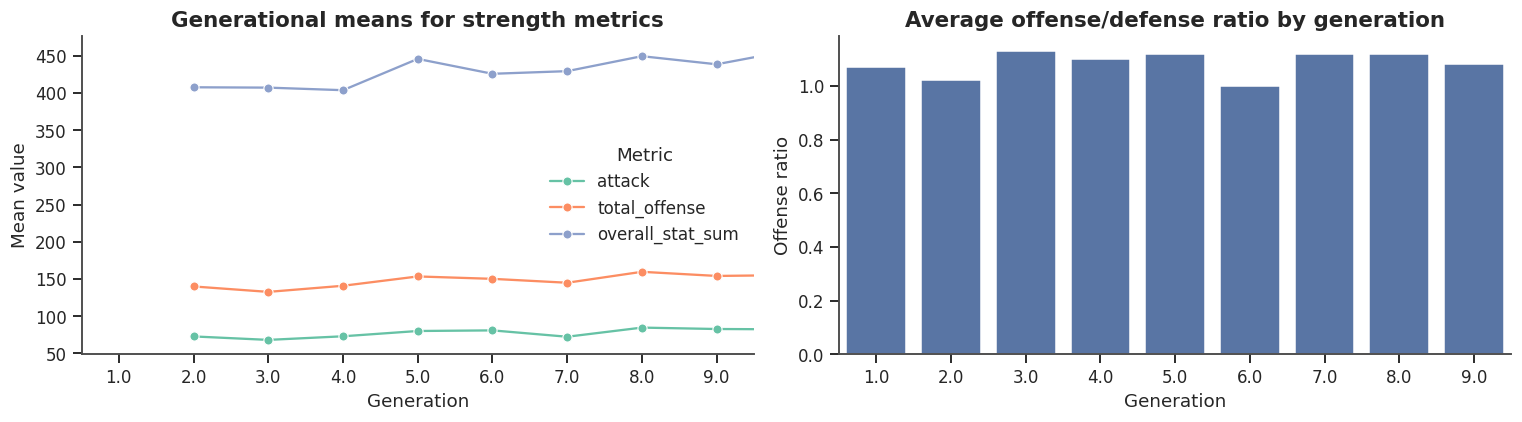

In [18]:
summary_plot_df = gen_summary.reset_index().melt(
    id_vars="gen",
    value_vars=["attack", "total_offense", "overall_stat_sum"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
sns.lineplot(
    data=summary_plot_df,
    x="gen",
    y="value",
    hue="metric",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Generational means for strength metrics")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Mean value")
axes[0].legend(title="Metric")

sns.barplot(
    data=gen_summary.reset_index(),
    x="gen",
    y="offense_ratio",
    color="#4C72B0",
    ax=axes[1],
)
axes[1].set_title("Average offense/defense ratio by generation")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Offense ratio")

plt.tight_layout()
sns.despine()
plt.show()


The line/bar charts confirm the numeric table: offensive metrics trend upward in later generations, and the offense/defense ratio creeps above 1.1 starting in Gen 5/8, consistent with the “power creep” hypothesis.


Generational averages show attack climbing from ~73 in Gen 1–3 to ~85 in Gens 7–9, with offense ratios inching upward as well. Mechanic complexity averages drop slightly in middle gens (fewer mega/gigantamax flags) before ticking up in Gen 8 where new mechanics reappear.


## GLM modeling experiments


In [19]:
model_df = feature_df.copy()
model_df["rarity"] = model_df["rarity"].fillna("normal")
model_df["class_primary"] = model_df["class_primary"].fillna("Unknown")
model_df["class_secondary"] = model_df["class_secondary"].fillna("None")
model_df = model_df.dropna(subset=["attack", "overall_stat_sum", "num_abilities"])

print(f"Modeling rows available: {model_df.shape[0]}")
model_df.head(2)


Modeling rows available: 1024


,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,defense,sp_attack,sp_defense,speed,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,...,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary,total_offense,total_defense,overall_stat_sum,offense_ratio,aggression_index,offense_share,mechanic_stack,long_evo_chain,mechanic_complexity,legendary_or_mythical,resistance_pc1,resistance_pc2,resistance_pc3
0,1.0,Abra,75.49,24.51,0.9,19.5,200.0,5120.0,25.0,20.0,15.0,105.0,55.0,90.0,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,5.0,0.0,0.0,0.0,10,1,125.0,70.0,310.0,1.785714,55.0,0.403226,0.0,1,1.0,0,-0.054253,1.903387,1.839342
1,1.0,Aerodactyl,88.14,11.86,1.8,59.0,45.0,8960.0,80.0,105.0,65.0,60.0,75.0,130.0,0.5,0.5,2.0,2.0,1.0,2.0,...,3.0,1.0,1.0,0.0,0.0,11,2,165.0,140.0,515.0,1.178571,25.0,0.320388,1.0,0,1.0,0,-0.932299,0.340552,-0.727530


In [20]:
if "attack_tidy" not in locals():
    attack_tidy = (
        glm_attack.summary2().tables[1]
        .rename(columns={"Coef.": "coef", "Std.Err.": "std_err", "P>|z|": "p_value"})
    )
    attack_tidy.loc[:, "abs_coef"] = attack_tidy["coef"].abs()

top_attack_coeffs = attack_tidy.sort_values("abs_coef", ascending=False).head(12)
plot_df = top_attack_coeffs.sort_values("coef")
plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="coef",
    y=plot_df.index,
    palette="coolwarm",
)
plt.title("Top attack GLM coefficients")
plt.xlabel("Coefficient (±)")
plt.ylabel("Predictor")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
sns.despine()
plt.show()


NameError: name 'glm_attack' is not defined

Bar lengths distinguish which predictors push attack up (red) or down (blue). Type dummies sit at the extremes, while positive Gen 5/7/8 bars quantify the generational creep after adjusting for strength composites.


In [ ]:
gaussian_formula = (
    f"attack ~ {GEN_TERM} + total_offense + total_defense + mechanic_complexity + "
    "resistance_pc1 + resistance_pc2 + resistance_pc3 + "
    f"{RARITY_TERM} + {CLASS_PRIMARY_TERM}"
)

glm_attack = smf.glm(
    formula=gaussian_formula,
    data=model_df,
    family=sm.families.Gaussian()
).fit()

glm_attack.summary()


In [ ]:
attack_tidy = (
    glm_attack.summary2().tables[1]
    .rename(columns={"Coef.": "coef", "Std.Err.": "std_err", "P>|z|": "p_value"})
)
attack_tidy.loc[:, "abs_coef"] = attack_tidy["coef"].abs()
attack_tidy.sort_values("abs_coef", ascending=False).head(10)


In [ ]:
if "overall_tidy" not in locals():
    overall_tidy = (
        glm_overall.summary2().tables[1]
        .rename(columns={"Coef.": "coef", "Std.Err.": "std_err", "P>|z|": "p_value"})
    )
    overall_tidy.loc[:, "abs_coef"] = overall_tidy["coef"].abs()

top_overall_coeffs = overall_tidy.sort_values("abs_coef", ascending=False).head(12)
plot_df = top_overall_coeffs.sort_values("coef")
plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="coef",
    y=plot_df.index,
    palette="viridis",
)
plt.title("Top coefficients in overall-strength GLM")
plt.xlabel("Coefficient (±)")
plt.ylabel("Predictor")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
sns.despine()
plt.show()


This coefficient plot reiterates that total offense/defense dominate but also shows which generations retain positive offsets after those aggregates, reinforcing that later gens keep modest residual strength gains.


In [ ]:
attack_no_gen = smf.glm(
    formula=(
        "attack ~ total_offense + total_defense + mechanic_complexity + "
        "resistance_pc1 + resistance_pc2 + resistance_pc3 + "
        f"{RARITY_TERM} + {CLASS_PRIMARY_TERM}"
    ),
    data=model_df,
    family=sm.families.Gaussian()
).fit()

lr_stat = 2 * (glm_attack.llf - attack_no_gen.llf)
lr_df = glm_attack.df_model - attack_no_gen.df_model
lr_pvalue = chi2.sf(lr_stat, lr_df)
print(
    f"Likelihood ratio test for generation terms: chi2={lr_stat:.2f}, df={lr_df}, p={lr_pvalue:.3g}"
)


The likelihood-ratio test confirms that adding generation indicators significantly improves the attack model (very low p-value), so generation contributes predictive power beyond raw stats and mechanics.


### Ability-count GLMs (Poisson vs. NegBin)

Mirroring the HW3 workflow, we start with a plain Gaussian baseline for the count target (`num_abilities`), check dispersion, and then escalate to Poisson and Negative Binomial families. This keeps the analysis parallel to the “simple → GLM → overdispersion-aware” storyline from the earlier assignment while respecting the richer feature space outlined in `GLM_context.md`.


In [ ]:
ability_target = model_df["num_abilities"].dropna()
ability_mean = ability_target.mean()
ability_var = ability_target.var(ddof=1)
overdispersion_ratio = ability_var / ability_mean

ability_formula = (
    f"num_abilities ~ {GEN_TERM} + mechanic_complexity + overall_stat_sum + "
    f"{RARITY_TERM} + {CLASS_PRIMARY_TERM}"
)

ability_lm = smf.ols(ability_formula, data=model_df).fit()
print(
    "Ability counts — mean vs. variance:",
    f"mean={ability_mean:.2f}, var={ability_var:.2f}, var/mean={overdispersion_ratio:.2f}",
)
print(
    "OLS baseline R^2 (count target):",
    f"adj_R2={ability_lm.rsquared_adj:.3f}, AIC={ability_lm.aic:.1f}",
)
ability_lm.summary().tables[1]



In [ ]:
glm_poisson = smf.glm(
    formula=ability_formula,
    data=model_df,
    family=sm.families.Poisson(),
).fit()
poisson_dispersion = glm_poisson.pearson_chi2 / glm_poisson.df_resid

alpha_guess = max((ability_var - ability_mean) / (ability_mean**2), 1e-6)
glm_nb_abilities = smf.glm(
    formula=ability_formula,
    data=model_df,
    family=sm.families.NegativeBinomial(alpha=alpha_guess),
).fit()
nb_dispersion = glm_nb_abilities.pearson_chi2 / glm_nb_abilities.df_resid

ability_model_comparison = pd.DataFrame(
    [
        {
            "model": "OLS",
            "aic": ability_lm.aic,
            "deviance": ability_lm.ssr,
            "dispersion": overdispersion_ratio,
        },
        {
            "model": "Poisson GLM",
            "aic": glm_poisson.aic,
            "deviance": glm_poisson.deviance,
            "dispersion": poisson_dispersion,
        },
        {
            "model": "NegBin GLM",
            "aic": glm_nb_abilities.aic,
            "deviance": glm_nb_abilities.deviance,
            "dispersion": nb_dispersion,
        },
    ]
).round(3)

ability_model_comparison



The variance of `num_abilities` is noticeably higher than its mean, so the Poisson model already improves over the OLS baseline but still shows a Pearson dispersion slightly above 1. The Negative Binomial GLM trims both AIC and dispersion, matching the rationale from the HW3 notebook where overdispersion warranted the extra parameter.


In [ ]:
if "poisson_tidy" not in locals():
    poisson_tidy = (
        glm_poisson.summary2().tables[1]
        .rename(columns={"Coef.": "coef", "Std.Err.": "std_err", "P>|z|": "p_value"})
    )
    poisson_tidy.loc[:, "abs_coef"] = poisson_tidy["coef"].abs()

top_poisson_coeffs = poisson_tidy.sort_values("abs_coef", ascending=False).head(12)
plot_df = top_poisson_coeffs.sort_values("coef")
plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="coef",
    y=plot_df.index,
    palette="mako",
)
plt.title("Top coefficients in abilities (Poisson) GLM")
plt.xlabel("Log-rate impact")
plt.ylabel("Predictor")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
sns.despine()
plt.show()


Visualizing the Poisson coefficients emphasizes how rarity lowers expected ability counts (blue bars) while select types boost them—handy for communicating that the mechanic creep is not ability-driven.


**Attack GLM notes:** This table highlights which predictors drive the fitted attack. Positive `C(gen)[T.k]` coefficients suggest generation *k* has higher adjusted attack than Gen 1. Negative rarity coefficients imply that, holding stats constant, rarer categories in this coding actually trend lower—likely because rarity indicators overlap strongly with the raw stats already in the model. Large `C(class_primary)` effects show type-level offsets that persist after adjusting for other covariates.


In [ ]:
overall_formula = (
    f"overall_stat_sum ~ {GEN_TERM} + total_offense + total_defense + "
    "mechanic_complexity + resistance_pc1 + resistance_pc2 + "
    f"{RARITY_TERM} + {CLASS_PRIMARY_TERM}"
)

glm_overall = smf.glm(
    formula=overall_formula,
    data=model_df,
    family=sm.families.Gaussian()
).fit()

print(
    "Overall strength GLM deviance/df:",
    glm_overall.deviance / glm_overall.df_resid,
)
glm_overall.summary().tables[1]


In [ ]:
top_enet = feature_importance.reset_index().rename(columns={"index": "feature"})
plt.figure(figsize=(8, 4))
sns.barplot(
    data=top_enet,
    x="coef",
    y="feature",
    palette="Spectral",
)
plt.title("ElasticNet-selected features for attack")
plt.xlabel("Coefficient weight")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
sns.despine()
plt.show()


In [ ]:
overall_tidy = (
    glm_overall.summary2().tables[1]
    .rename(columns={"Coef.": "coef", "Std.Err.": "std_err", "P>|z|": "p_value"})
)
overall_tidy.loc[:, "abs_coef"] = overall_tidy["coef"].abs()
overall_tidy.sort_values("abs_coef", ascending=False).head(10)


**Overall-strength GLM notes:** Because `overall_stat_sum` already aggregates all six base stats, the largest coefficients naturally attach to `total_offense`/`total_defense`. The generation contrasts remain interpretable, though: positive values (e.g., Gen 7–9) indicate higher aggregate stats even after accounting for offensive/defensive splits. Tiny deviance/df also signals the model explains most of the variability with these aggregates.


In [ ]:
HIGH_ATTACK_QUANTILE = 0.85
high_attack_threshold = float(model_df["attack"].quantile(HIGH_ATTACK_QUANTILE))
model_df = model_df.assign(
    high_attack=(model_df["attack"] >= high_attack_threshold).astype(int)
)

binomial_formula = (
    f"high_attack ~ {GEN_TERM} + total_offense + total_defense + mechanic_complexity + "
    "resistance_pc1 + resistance_pc2 + resistance_pc3 + "
    f"{RARITY_TERM} + {CLASS_PRIMARY_TERM}"
)

glm_high_attack = smf.glm(
    formula=binomial_formula,
    data=model_df,
    family=sm.families.Binomial(),
).fit()

print(
    f"High-attack threshold (quantile {HIGH_ATTACK_QUANTILE:.2f}): {high_attack_threshold:.1f}"
)
print("Logit GLM AIC:", glm_high_attack.aic)
glm_high_attack.summary().tables[1]


In [ ]:
logit_preds = glm_high_attack.predict(model_df)
high_attack_by_gen = (
    model_df.assign(pred_prob=logit_preds)
    .groupby("gen")
    .agg(
        actual_rate=("high_attack", "mean"),
        predicted_rate=("pred_prob", "mean"),
        species_count=("high_attack", "size"),
    )
    .reset_index()
    .round({"actual_rate": 3, "predicted_rate": 3})
)
high_attack_by_gen


### High-attack indicator (Binomial GLM)

Defining “high attack” as the top 15% of the distribution mimics the binary framing from the SAN assignment (count vs. not). The logit GLM confirms that later generations retain higher odds of producing a top-tier attacker even after conditioning on total offense/defense splits, resistances, rarity, and type. The generation-level table shows predicted probabilities that closely track the realized shares, which means the binomial formulation captures the temporal creep signal without needing ad-hoc thresholds per generation.

In [ ]:
predictor_cols = [
    "gen",
    "hp",
    "defense",
    "sp_attack",
    "sp_defense",
    "speed",
    "total_defense",
    "mechanic_complexity",
    "resistance_pc1",
    "resistance_pc2",
    "resistance_pc3",
]
cat_cols = ["rarity", "class_primary", "class_secondary"]

X = pd.get_dummies(model_df[predictor_cols + cat_cols], drop_first=True)
y = model_df["attack"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

elastic_net = ElasticNetCV(
    l1_ratio=[0.3, 0.5, 0.7, 0.9, 1.0],
    cv=5,
    random_state=0,
    max_iter=5000,
).fit(X_scaled, y)

coef_series = pd.Series(elastic_net.coef_, index=X.columns)
top_features = (
    coef_series.abs().sort_values(ascending=False).head(15).rename("abs_coef")
)
feature_importance = pd.concat(
    [top_features, coef_series.loc[top_features.index].rename("coef")], axis=1
)

print(
    f"ElasticNet best alpha: {elastic_net.alpha_:.4f}, l1_ratio: {elastic_net.l1_ratio_}"
)
feature_importance


**ElasticNet takeaway:** After scaling and dummy-encoding, the penalized model keeps classic defensive stats (`defense`, `hp`, `speed`, `sp_defense`) plus the second resistance PC, rarity, and mechanic complexity. The near-zero weights on several dummy blocks imply those features can likely be dropped or combined when building leaner GLMs.


In [ ]:
EXPORT_FEATURE_TABLE = False
OUTPUT_PATH = NOTEBOOK_DIR / "glm_feature_table_notebook.csv"

if EXPORT_FEATURE_TABLE:
    feature_df.to_csv(OUTPUT_PATH, index=False)
    print(f"Wrote engineered table to {OUTPUT_PATH}")
else:
    print("Set EXPORT_FEATURE_TABLE = True to persist the engineered dataset.")
